# Missing Hospital Appointments
By Jessica Hislop, Jasper Cordero and Momina Amin

# Business problem: 
Why are patients missing appointments, and how can hospitals reduce no show appoinments?

## Why is this problem important?
Missing hospital appointments have a significant impact on the quality of healthcare services. They can lead to inefficient resource allocation, lost revenue, and increased waiting times for other patients. Furthermore, missing appointments may delay diagnosis and treatment plans which can negatively affect patient outcomes. Therefore, it is important for hospitals to understand the reasons why patients fail to attend their appointments, and to develop strategies that will reduce no-show rates and improve overall patient care.

# Dataset:
The dataset we chose is a hospital appointment no-show prediction dataset.

## Why we chose this dataset:
The Hospital appointment prediction dataset from Kaggle is suitable for our project because it directly aligns with our core  business problem of predicting which patients are likely to miss their appointments.The dataset includes a wide range of demographics and appointment related variables making it more inclusive and comprehensive for analysis.  Since  the target variable is binary , it makes it easier and suitable to use classification models such as regression , decision trees etc…Furthermore, this is a synthetic dataset which means that it does not include real patient records or personal information. This ensures that the data chosen complies with GDPR regulations and keeps data protected. The dataset also provides for exploratory  data analysis and machine learning, allowing us to identify key patterns and risk factors why many people missed appointments. Overall , it enables us to develop a predictive model that can help healthcare providers improve resource allocation , reduce wasted appointment slots and enhance operational efficiency within healthcare services. 


# Understanding the dataset

This section will be use understanding the no-show appointment dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("hospital_appointment_no_show_5000 3.csv")
df.head()
#Preview of the dataset to check it has loaded correctly

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0.0,1,NaN,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0.0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0.0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1.0,1,NaN,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0.0,1,NaN,Secondary,Insured,0,0,1


In [2]:
df.shape
#Total rows and columns

(5000, 24)

In [3]:
df.info()
#Shows which columns are numeric, categorical and if there are missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    4610 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            4612 non-null   float64
 5   travel_time_min        4584 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

Columns that have missing values: age, distance_km, travel_time_min, email_reminder, employment_status, education_level

In [4]:
missing = df.isnull().sum()
missing[missing > 0]
# How much is missing from each category

age                  390
distance_km          388
travel_time_min      416
email_reminder       440
employment_status    388
education_level      391
dtype: int64

In [5]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]
# Percentage output of missing values

email_reminder       8.80
travel_time_min      8.32
education_level      7.82
age                  7.80
distance_km          7.76
employment_status    7.76
dtype: float64

The missing values do not exceed 10%, it makes more sense to impute instead of delete data.

In [6]:
df["no_show"].value_counts()
df["no_show"].value_counts(normalize=True)

no_show
1    0.5
0    0.5
Name: proportion, dtype: float64

Data is perfectly balanced 50/50.

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: Index(['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show'],
      dtype='object')
Categorical: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


The dataset variables were sperated into groups (numeric or categorical) based on their data types. This will help ensure the data set is analysed and visualised with the appropriate methods.

In [8]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,5000.000000,4610.000000,4612.000000,4584.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,4560.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,39.643167,8.310169,41.967779,6.990600,2.005600,0.40180,0.186200,0.287200,0.476400,0.706800,0.401535,1.404200,0.207000,0.099800,0.50000
std,1443.520003,14.925693,4.604878,23.271754,2.671917,1.423227,0.64687,0.389307,0.452501,0.499493,0.455275,0.490263,0.814466,0.405196,0.299763,0.50005
min,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1250.750000,30.000000,4.800000,23.600000,5.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000
50%,2500.500000,40.000000,8.100000,40.700000,7.000000,2.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.50000
75%,3750.250000,49.750000,11.400000,57.525000,9.000000,3.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.00000
max,5000.000000,90.000000,30.400000,128.400000,21.000000,9.000000,5.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.00000


This table shows a statistical summary of the numerical variables. It provides an overview of the central tendency and distribution. This table allows us to give a quick check for possible outliers, missing data and errors.

# Cleaning the data

## Handling missing values

The dataset contains missing values in the age, distance_km, travel_time_min, education_level, and employment_status columns. The missing values are under 10% which is relatively small suggesting that the missing data is random. Instead of removing rows and reducing the dataset, we used imputation techniques to preserve the available data.

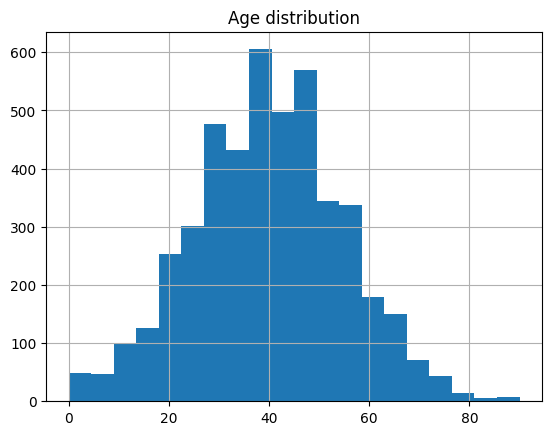

In [9]:
df["age"].hist(bins=20)
plt.title("Age distribution")
plt.show()

In [10]:
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

In [11]:
df["age"].isnull().sum()

np.int64(0)

To handle missing values in the age category we used a histogram to analyse the distribution. It shows a slightly skewed distribution, with majority between 25 and 50 years. Due to this skewed distribution, we used median imputation instead of the mean as it is less likely to be effected by outliers. After filling out the values with the median age, we checked to confirm there were no missing values in the age column. 

In [12]:
median_distance = df["distance_km"].median()
df["distance_km"] = df["distance_km"].fillna(median_distance)

In [13]:
df["distance_km"].isnull().sum()

np.int64(0)

In [14]:
median_travel = df["travel_time_min"].median()
df["travel_time_min"] = df["travel_time_min"].fillna(median_travel)

In [15]:
df["travel_time_min"].isnull().sum()

np.int64(0)

Median imputation was also used to handle the missing values in the numerical variables distance_km and travel_time_min. This was chosen as the median is less sensitive to extrea, values and provides a reliable measure of central tendency. After a check was used to confirm there are no missing values in these columns. 

In [16]:
mode_email = df["email_reminder"].mode()[0]
df["email_reminder"] = df["email_reminder"].fillna(mode_email)

In [17]:
df["email_reminder"].isnull().sum()

np.int64(0)

In [18]:
mode_employment = df["employment_status"].mode()[0]
df["employment_status"] = df["employment_status"].fillna(mode_employment)

In [19]:
df["employment_status"].isnull().sum()

np.int64(0)

In [20]:
mode_education = df["education_level"].mode()[0]
df["education_level"] = df["education_level"].fillna(mode_education)

In [21]:
df["education_level"].isnull().sum()

np.int64(0)

For the email_reminder, employment_status, and education_level missing data mode imputation was used. This method was chosen as the columns are categorical therefore mean or median cannot be used. The mode method is most commonly used to replace values without disorting the dataset. A check was used after impution to verfiy there are no missing values left in these columns. 

In [22]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
city_type                0
distance_km              0
travel_time_min          0
appointment_day          0
appointment_time_slot    0
department               0
waiting_days             0
previous_appointments    0
previous_no_shows        0
diabetes                 0
hypertension             0
chronic_disease          0
sms_reminder             0
email_reminder           0
num_reminders            0
employment_status        0
education_level          0
insurance_status         0
rainy_day                0
public_holiday           0
no_show                  0
dtype: int64

A final check to ensure there are no missing values remaining in the dataset.

## Duplicate rows

In [23]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows in the dataset.

## Data types

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    5000 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            5000 non-null   float64
 5   travel_time_min        5000 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

This table shows us the different data types for each variable, we can analyse to see if the data types are appropriate for that variable. Where another type would fit better we will change it. 

In [25]:
df["email_reminder"] = df["email_reminder"].astype(int)

The email_reminder variable makes more sense being integer instead of float.

In [26]:
categorical_cols = [
    "gender", "city_type", "appointment_day", 
    "appointment_time_slot", "department", 
    "employment_status", "education_level",
    "insurance_status"
]
for col in categorical_cols:
    df[col] = df[col].astype("category")

These variables have been converted to category data type to better represent categorical information and increase analysis efficiency later on.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   patient_id             5000 non-null   int64   
 1   age                    5000 non-null   float64 
 2   gender                 5000 non-null   category
 3   city_type              5000 non-null   category
 4   distance_km            5000 non-null   float64 
 5   travel_time_min        5000 non-null   float64 
 6   appointment_day        5000 non-null   category
 7   appointment_time_slot  5000 non-null   category
 8   department             5000 non-null   category
 9   waiting_days           5000 non-null   int64   
 10  previous_appointments  5000 non-null   int64   
 11  previous_no_shows      5000 non-null   int64   
 12  diabetes               5000 non-null   int64   
 13  hypertension           5000 non-null   int64   
 14  chronic_disease        5000 non-null   i

This table provides the variables with their new data types.

## Value range checks

In [28]:
df["age"].describe()

count    5000.000000
mean       39.671000
std        14.331973
min         0.000000
25%        31.000000
50%        40.000000
75%        49.000000
max        90.000000
Name: age, dtype: float64

In [29]:
df[df["distance_km"] < 0]
df[df["travel_time_min"] < 0]
df[df["waiting_days"] < 0]

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show


The numerical variables were reviewed to ensure the dataset is realistc, such as no negative numbers in age or extreamly high travel times.

## Binary variables check

In [30]:
binary_cols = [
    "diabetes", "hypertension", "chronic_disease",
    "sms_reminder", "email_reminder",
    "rainy_day", "public_holiday", "no_show"
]
for col in binary_cols:
    print(col, df[col].unique())

diabetes [0 1]
hypertension [0 1]
chronic_disease [0 1]
sms_reminder [1 0]
email_reminder [0 1]
rainy_day [1 0]
public_holiday [0 1]
no_show [1 0]


Binary variables were checked to ensure they contained only vaild binary values (0 and 1), the output confirmed their values and no further cleaning is required.

## Categorical values check

In [31]:
categorical_cols = [
    "gender", "city_type", "appointment_day",
    "appointment_time_slot", "department", 
    "employment_status", "education_level", "insurance_status"
]
for col in categorical_cols:
    print(col, df[col].astype(str).unique())

gender ['Female' 'Male']
city_type ['Suburban' 'Rural' 'Urban']
appointment_day ['Sat' 'Tue' 'Thu' 'Fri' 'Wed' 'Mon']
appointment_time_slot ['Evening' 'Morning' 'Afternoon']
department ['Pediatrics' 'Cardiology' 'General Medicine' 'Dermatology' 'Orthopedics']
employment_status ['Employed' 'Unemployed' 'Student']
education_level ['Higher' 'Secondary' 'Primary']
insurance_status ['Uninsured' 'Insured']


The categorical variables were checked to confirm they are consistent and formatted correctly. The output shows that there are no irregular values.

## Checking for outliers

In [32]:
df[["age","distance_km","travel_time_min","waiting_days"]].describe()

,age,distance_km,travel_time_min,waiting_days
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,39.671000,8.293860,41.862300,6.990600
std,14.331973,4.422922,22.285178,2.671917
min,0.000000,0.000000,5.000000,0.000000
25%,31.000000,5.100000,25.300000,5.000000
50%,40.000000,8.100000,40.700000,7.000000
75%,49.000000,11.100000,55.600000,9.000000
max,90.000000,30.400000,128.400000,21.000000


This numerical statistical summary table was used to help identify outliers in the dataset. All the variables fall in reasonable ranges for their variables, meaning there are no extreme outliers and no futher cleaning was required.

In [34]:
df.to_csv("cleaned_hospital_dataset.csv", index=False)

This code saves the new cleaned dataset to the folder to allow for visualisations and further analysis.

# Visualisations

In [36]:
import pandas as pd
df = pd.read_csv("cleaned_hospital_dataset.csv")

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_hospital_dataset.csv")

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("cleaned_hospital_dataset.csv")

# view first rows
df.head()

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0,1,Employed,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1,1,Employed,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0,1,Employed,Secondary,Insured,0,0,1


### Age Histogram

Age histogram represents a symmetrical distribution surrounded around middle ages patients between 30-40 years. This makes the assumption that healthcare demand is mainly for working individuals who are economically stable. 

This distribution suggests that appointment scheduling and communication techniques should be improved for this age group by allowing flexible schdedule times. The histogram does not give reasoning for behavioural difference in attendance. For example, old people may have issues in mobility which impacts them not turning up to their appointment. 

A weakenss of this histogram is that it only shows frequency distribution not the relationship between and age and missed appointments. 

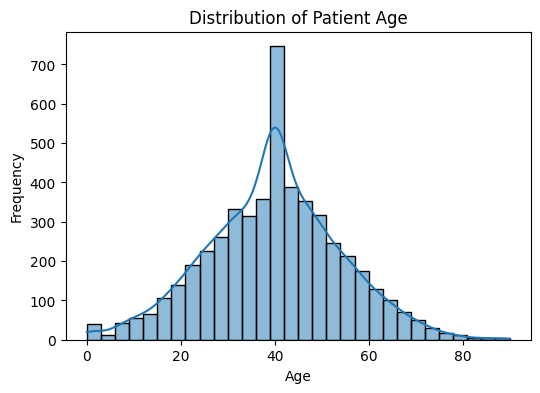

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Distance to hospital histogram

The distance to hospital histogram visualises a positvely skewed distribution meaning majority of the patients live near the healthcare service whilst a some patients live further away. This suggests imbalanced location accessibility which impacts whether patients show up or not and how regularly do they attend their appointments. 

The patients who live further away have to find transportation which increases their cost and could cause issues with planning their timings for transport and attending their appointment. Due to this, patients are highly likely to miss their appointment and decrease engagement levels. 

On the other hand, there are some patients that will attend their appointment regardless of distance as they take importance for their medical treatments. This shows the distrubtion does not confirm the cause of missed appointments is distance.

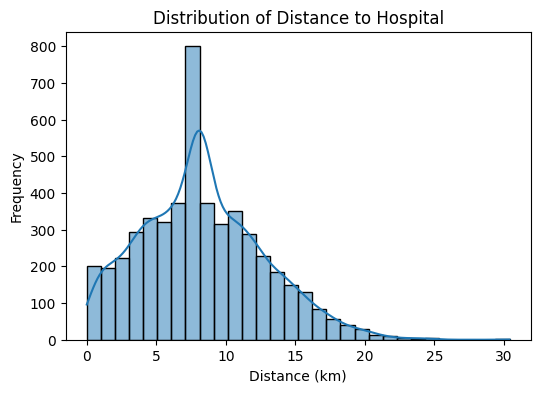

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(df['distance_km'], bins=30, kde=True)
plt.title("Distribution of Distance to Hospital")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

### Waiting days histogram

Waiting days histogram shows a right skewed distribution meaning majority of the patients get appointments in a short waiting time whilst a small group of patients have to wait longer for an appointment. This makes the assumption that there is possible inefficiency in recieving appointments due to high waiting demand. 

Due to the long waiting times it can result in patients being unsatisfied leading to them not attending their appointments or scheduling an appointment. This creates a chance for hospitals to lower their waiting times to increase attendance levels. 

Waiting times is not entirely always the reason for missed appointments as some patients may wait longer for important medical requirements. By joining this variable with predicitive modelling techniques will give a better insight to its impact. 


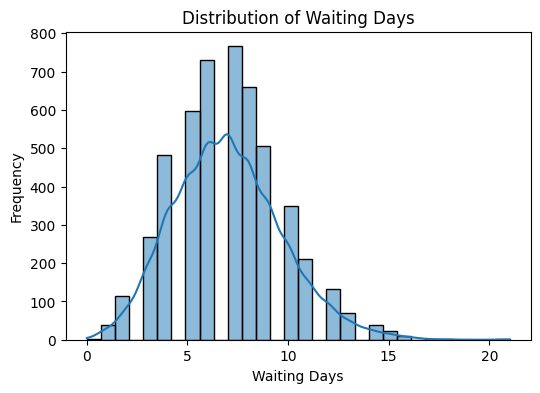

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['waiting_days'], bins=30, kde=True)
plt.title("Distribution of Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")
plt.show()

### Previous no show histogram

The previous no show histogram shows a highly postively skewed distribution meaning majority of the patients have no missed appointments and a small group of patients have missed appointments. This indicates the presence of distinct behavioural groups in the patient sample group. 

By idenitifying patients who constantly miss their appointments can lower the financial loss caused by missed appointments. This can be done by sending reminders to patients or warning patients with penalties. 

The histogram does not explain other factors like economical issues, mental illnesses or other commitment issues. These factors could impact why patients miss their appointments. Clustering analysis or segmentation is needed to find the cause behind this distribution. 

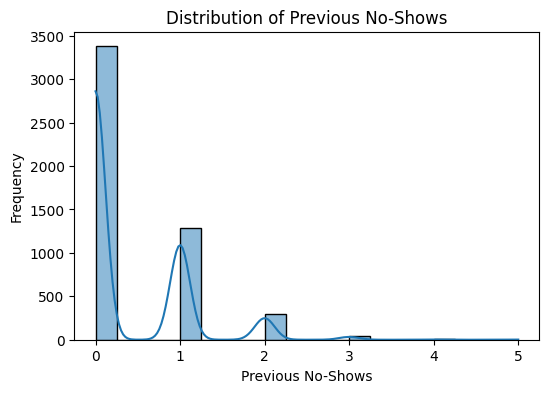

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['previous_no_shows'], bins=20, kde=True)
plt.title("Distribution of Previous No-Shows")
plt.xlabel("Previous No-Shows")
plt.ylabel("Frequency")
plt.show()

### Age boxplot

Age boxplot represents a moderate variability with a median around middle ages and very few outliers showing young or old patients. This means there is a stable demand over the age groups without extreme dispersion. 

The outliers may need specialised care like paediatric services. These types of groups would need personalised communication tools to lower their missed appointments. 

A weakness of the boxplot is it gives an overview of the distribution but does not indicate the behabvioural attendance differences. It needs ot be analused with histograms and comparative analysis. 

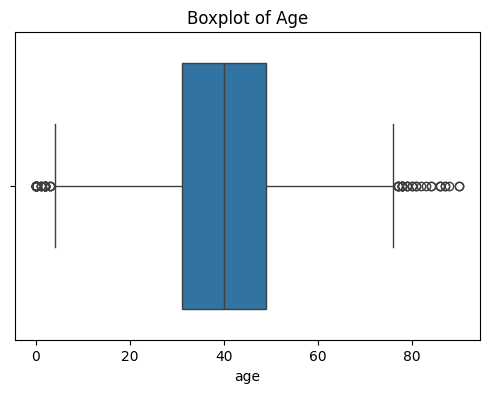

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

### Distance boxplot

The boxplot suggests majority of the patients live near the hospital as the middle range values is concentrated at lower distances. There are outliers who have a longer travel distance to attend their appointment. 

Patients who live further away are likely to miss their appointment. Hospitals should provide remote appointment opportunities or flexible timings. 

The boxplot does not fully reason distance causes a high level in show rates. A deeper analysis is needed to compare distance with behavioural reasons. 

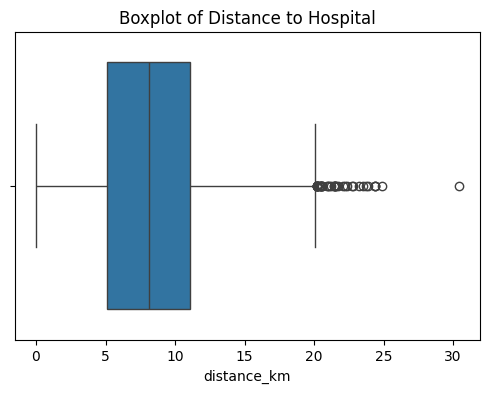

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['distance_km'])
plt.title("Boxplot of Distance to Hospital")
plt.show()

### Waiting days boxplot

The boxplot shows a significant spread of the existence of extreme outliers indicating inconistent appointment scheduling in the system. 

Long waiting periods can lower patient satisfaction and increase the likelihood of missed appointments. The watiting time could be due to high demand or insufficient resources in some departments. 

This boxplot does not fully reason the long waiting times. Predicitve modelling is required to understand the impact better. 



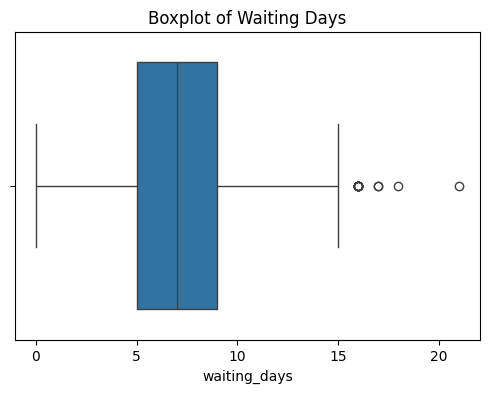

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['waiting_days'])
plt.title("Boxplot of Waiting Days")
plt.show()

### Previous no shows boxplot

This boxplot visualises a low median with extreme upper outliers showing that no show attendance is in a small group of patients. This trend shows that missed appointments are not random but due to behavioural, economical or social markers.

By targeting the small group of patients who do not attend their appointments could have a significant impact on efficiency levels. CLustering or classification are needed to find the techniques for these factors. 

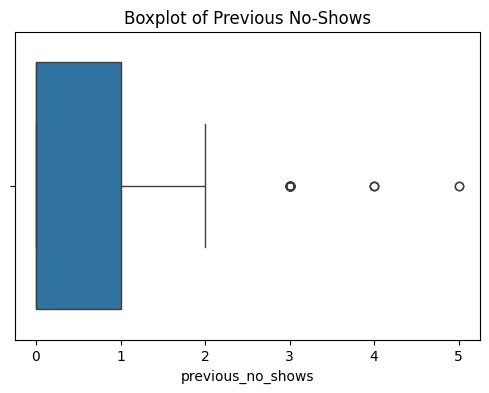

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['previous_no_shows'])
plt.title("Boxplot of Previous No-Shows")
plt.show()

## Transforming Data Types


To prepare the dataset for machine learning analysis, several data types needed to be transformed.

Some variables in the dataset were stored as text (categorical data) or date strings. Machine learning algorithms require numerical input, these variables were converted into appropriate formats.

Specifically:
- The appointment_day column was converted to a datetime format.
- Several categorical variables such as gender, city type, and department were encoded into numerical variables using one-hot encoding.

In [26]:
import pandas as pd

df = pd.read_csv("cleaned_hospital_dataset.csv")

### Encoding Appointment Day

The appointment_day variable originally contained categorical values representing the day of the week. 
Since machine learning models require numerical input, the day names are converted into numerical values. 
Each day is mapped to a number between 0 and 6, representing Monday to Sunday.

In [27]:
df['appointment_day'].head()

0    Sat
1    Tue
2    Sat
3    Thu
4    Fri
Name: appointment_day, dtype: object

In [28]:
df['appointment_day'].unique()

array(['Sat', 'Tue', 'Thu', 'Fri', 'Wed', 'Mon'], dtype=object)

In [29]:
df['appointment_day'] = df['appointment_day'].astype(str).str.strip()

In [30]:
day_mapping = {
    'Mon':0,
    'Tue':1,
    'Wed':2,
    'Thu':3,
    'Fri':4,
    'Sat':5,
    'Sun':6
}

df['appointment_day'] = df['appointment_day'].map(day_mapping)

In [31]:
df.head()

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,5,Evening,Pediatrics,8,...,0,1,0,1,Employed,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,1,Morning,Cardiology,8,...,1,1,0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,5,Evening,General Medicine,3,...,0,1,0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,3,Evening,General Medicine,12,...,1,0,1,1,Employed,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,4,Morning,Dermatology,8,...,0,1,0,1,Employed,Secondary,Insured,0,0,1


### Encoding Categorical Variables

Several columns in the dataset contain categorical text values such as gender, city type, appointment time slot, department, employment status, education level and insurance status.

To allow these variables to be used in machine learning models, they are transformed using one-hot encoding. This technique creates binary columns (0 or 1) for each category.

In [33]:
categorical_columns = [
    'gender',
    'city_type',
    'appointment_time_slot',
    'department',
    'employment_status',
    'education_level',
    'insurance_status'
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [35]:
df.head()

,patient_id,age,distance_km,travel_time_min,appointment_day,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,...,appointment_time_slot_Morning,department_Dermatology,department_General Medicine,department_Orthopedics,department_Pediatrics,employment_status_Student,employment_status_Unemployed,education_level_Primary,education_level_Secondary,insurance_status_Uninsured
0,1,47.0,16.5,77.3,5,8,2,0,0,0,...,False,False,False,False,True,False,False,False,False,True
1,2,37.0,6.7,26.9,1,8,1,0,1,0,...,True,False,False,False,False,False,False,False,True,False
2,3,49.0,8.2,46.1,5,3,1,0,0,0,...,False,False,True,False,False,False,True,False,True,False
3,4,62.0,2.6,15.2,3,12,1,0,0,1,...,False,False,True,False,False,False,False,False,True,False
4,5,36.0,4.1,13.8,4,8,0,0,0,0,...,True,True,False,False,False,False,False,False,True,False


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   int64  
 1   age                            5000 non-null   float64
 2   distance_km                    5000 non-null   float64
 3   travel_time_min                5000 non-null   float64
 4   appointment_day                5000 non-null   int64  
 5   waiting_days                   5000 non-null   int64  
 6   previous_appointments          5000 non-null   int64  
 7   previous_no_shows              5000 non-null   int64  
 8   diabetes                       5000 non-null   int64  
 9   hypertension                   5000 non-null   int64  
 10  chronic_disease                5000 non-null   int64  
 11  sms_reminder                   5000 non-null   int64  
 12  email_reminder                 5000 non-null   i

### Summary

In this stage, categorical variables were transformed into numerical format to prepare the dataset for machine learning analysis. 

The appointment_day variable was encoded by mapping each day of the week to a numerical value. Other categorical variables such as gender, department, and appointment time slot were converted using one-hot encoding.

These transformations ensure that the dataset contains numerical features that can be used effectively in predictive modelling.

In [36]:
df.info()

df.isnull().sum()

df.to_csv("processed_hospital_dataset.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   int64  
 1   age                            5000 non-null   float64
 2   distance_km                    5000 non-null   float64
 3   travel_time_min                5000 non-null   float64
 4   appointment_day                5000 non-null   int64  
 5   waiting_days                   5000 non-null   int64  
 6   previous_appointments          5000 non-null   int64  
 7   previous_no_shows              5000 non-null   int64  
 8   diabetes                       5000 non-null   int64  
 9   hypertension                   5000 non-null   int64  
 10  chronic_disease                5000 non-null   int64  
 11  sms_reminder                   5000 non-null   int64  
 12  email_reminder                 5000 non-null   i

### Stage 3: Data mining and Business insights

### Decision tree model

This model was designed to predict if a patient would miss their appointment. It can also show how different factors can impact whether a patient attends their appointment or not. 

The model gained this score:
 [[530 224]
 [448 298]] The confusion matrix represents how the model differentiates between the patients who attend and those who do not attend their appointment. 

 Feature splits in the tree indicate that factors like waiting days and previous no show represent a significant impact in predicting patient behaviour. This means hospitals are able to use these assumptions and factors to identify patients who require high level of treatment and send reminders to them. 

 One weakness of tree model is it doesnt really generalise to new data so by implementing random forest could enhance the accuracy. 

In [17]:
!pip install scikit-learn

     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
     - -------------------------------------- 0.3/8.9 MB 5.9 MB/s eta 0:00:02
     ------ --------------------------------- 1.4/8.9 MB 14.5 MB/s eta 0:00:01
     ------------------ --------------------- 4.0/8.9 MB 32.1 MB/s eta 0:00:01
     -------------------------------- ------- 7.2/8.9 MB 41.6 MB/s eta 0:00:01
     ---------------------------------------  8.9/8.9 MB 40.5 MB/s eta 0:00:01
     ---------------------------------------  8.9/8.9 MB 40.5 MB/s eta 0:00:01
     ---------------------------------------- 8.9/8.9 MB 28.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
     ------------------------------------- 309.1/309.1 kB 19.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
     -- ------------------------------------- 2.5/41.3 MB 77.8 MB/s eta 0:00:01
     ----- ---------------------------------- 5.6/41.3 MB 71.3 MB/s eta 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\momin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
features = ['age', 'distance_km', 'waiting_days', 'previous_no_shows']

X = df[features]
y = df['no_show']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [23]:
model = DecisionTreeClassifier(
    max_depth=4,     # prevents overfitting (important to mention)
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred = model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.552

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.70      0.61       754
           1       0.57      0.40      0.47       746

    accuracy                           0.55      1500
   macro avg       0.56      0.55      0.54      1500
weighted avg       0.56      0.55      0.54      1500


Confusion Matrix:

[[530 224]
 [448 298]]


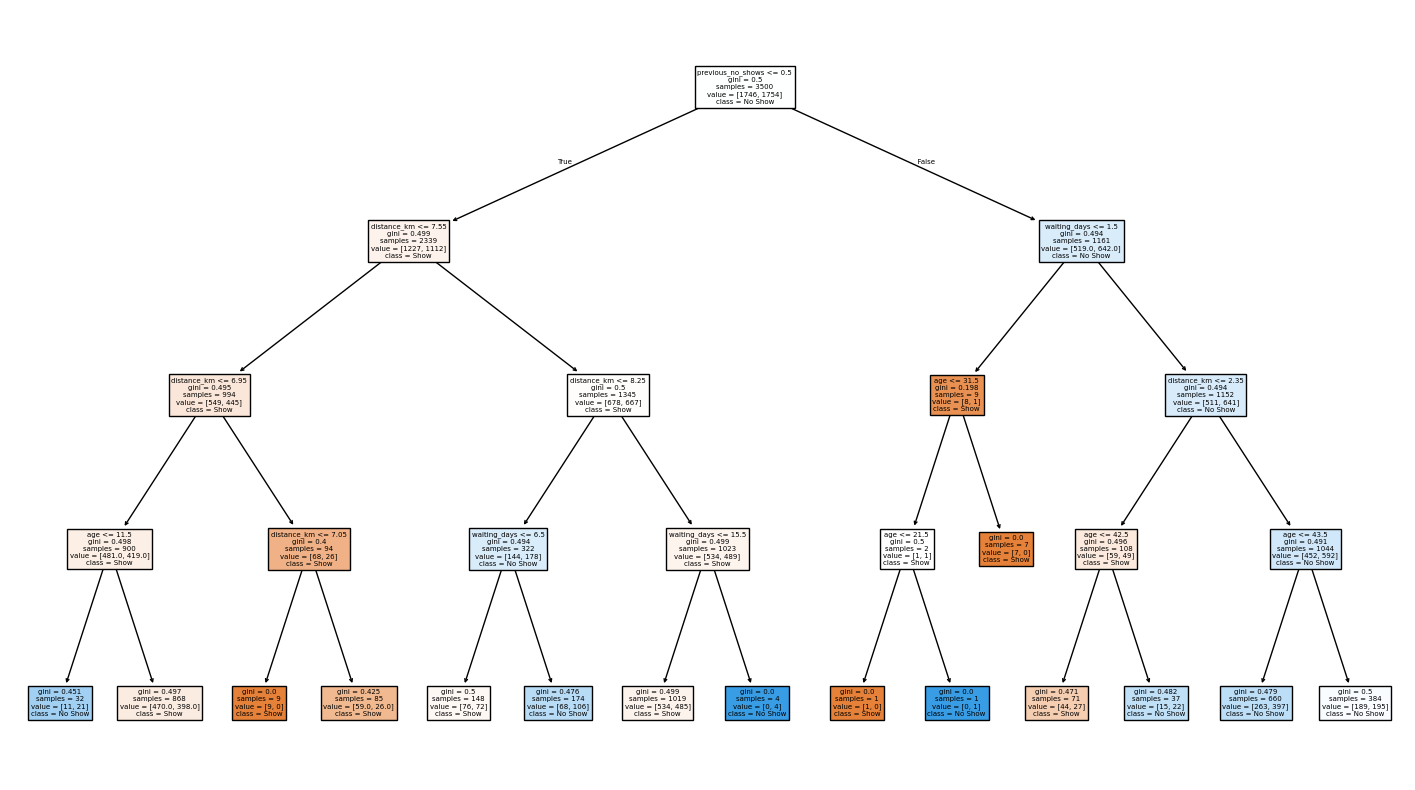

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=features,
          class_names=['Show','No Show'],
          filled=True)

plt.show()